# 02 - External Data EDA

Exploratory analysis for Google Maps / external review data and listing rating distributions.


**Data Collection Distribution by Number of Locations:**

Successfully processed: barcelona
Successfully processed: budapest
Successfully processed: buenos_aires
Successfully processed: cape_town
Successfully processed: lisbon
Successfully processed: mexico_city
Successfully processed: miami
Successfully processed: new_york
Successfully processed: paris
Successfully processed: phuket
Successfully processed: san_francisco
Successfully processed: sau_paulo
Successfully processed: tel_aviv
Successfully processed: tiberias
Successfully processed: tokyo


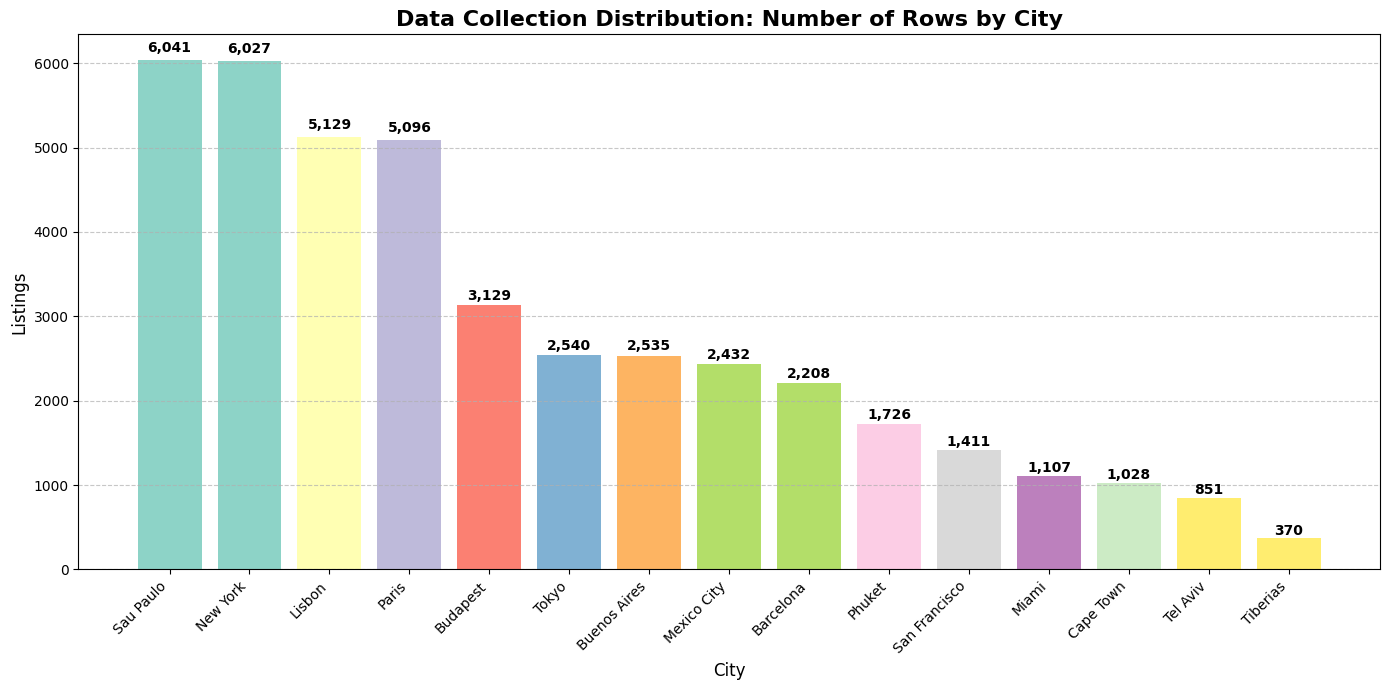

city_source,count
Sau Paulo,6041
New York,6027
Lisbon,5129
Paris,5096
Budapest,3129
Tokyo,2540
Buenos Aires,2535
Mexico City,2432
Barcelona,2208
Phuket,1726


In [0]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# 1. Setting up the list of cities 
cities = [
    "barcelona", "budapest", "buenos_aires", "cape_town", 
    "lisbon", "mexico_city", "miami", "new_york", 
    "paris", "phuket", "san_francisco", "sau_paulo", 
    "tel_aviv", "tiberias", "tokyo"
]

combined_df = None

for city in cities:
    file_path = f"{base_path}{city}_final.csv"
    try:
        df = (spark.read.format("csv")
              .option("header", "true")
              .option("inferSchema", "true")
              .option("multiLine", "true")  # Important for reviews with entries
              .option("escape", '"')        # Important for handling quotation marks within text
              .option("quote", '"')
              .load(file_path))
        
        # Unifying column names: If the city uses the lat/long abbreviation, we will convert to the full name
        if "lat" in df.columns:
            df = df.withColumnRenamed("lat", "latitude")
        if "long" in df.columns:
            df = df.withColumnRenamed("long", "longitude")
            
        # Remove junk columns created by read errors 
        bad_cols = [c for c in df.columns if c.startswith("_c")]
        df = df.drop(*bad_cols)
        
        # Adding the source column
        temp_df = df.withColumn("city_source", F.lit(city.replace("_", " ").title()))
        
        if combined_df is None:
            combined_df = temp_df
        else:
            # Using unionByName ensures that the columns are joined by name and not by position
            combined_df = combined_df.unionByName(temp_df, allowMissingColumns=True)
            
        print(f"Successfully processed: {city}")
    except Exception as e:
        print(f"Error loading {city}: {e}")

# 2. Calculating statistics for a graph
stats_df = combined_df.groupBy("city_source").count().toPandas()
stats_df = stats_df.sort_values(by="count", ascending=False)

# 3. Creating the graph
plt.figure(figsize=(14, 7))
colors = plt.cm.Set3(np.linspace(0, 1, len(stats_df)))

bars = plt.bar(stats_df['city_source'], stats_df['count'], color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), 
             f'{int(yval):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Data Collection Distribution: Number of Rows by City', fontsize=16, fontweight="bold")
plt.xlabel('City', fontsize=12)
plt.ylabel('Listings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
display(combined_df.groupBy("city_source").count().orderBy(F.desc("count")))

**External Review Text Analysis:**

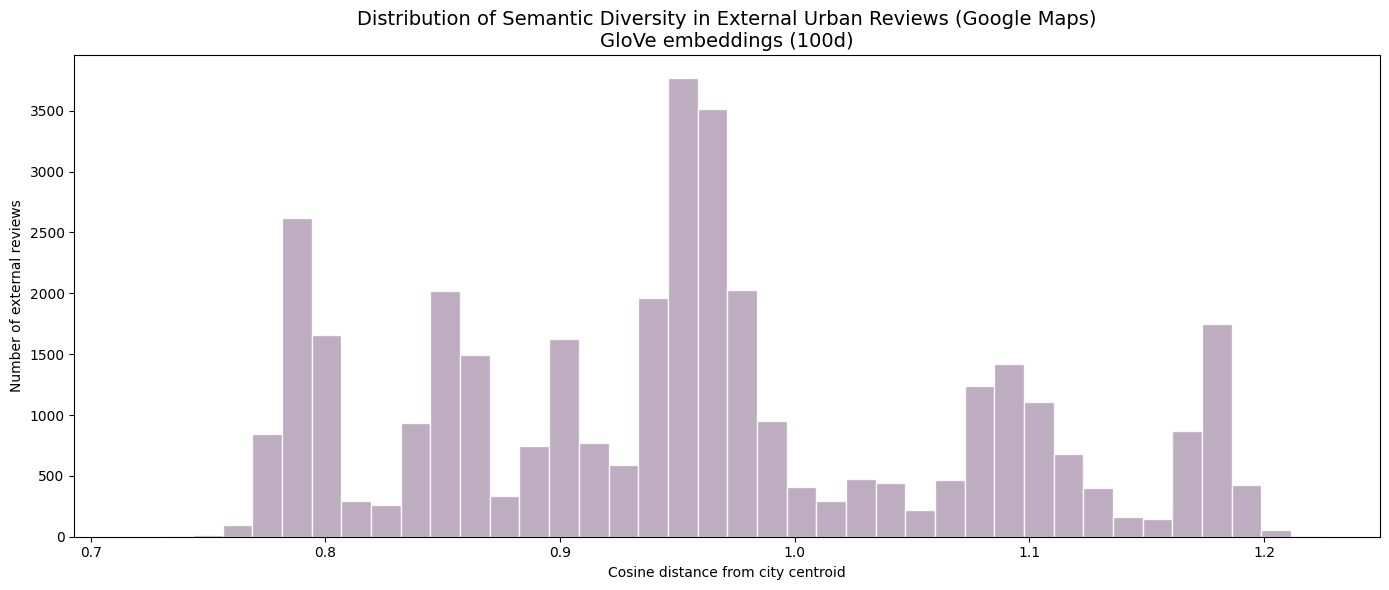

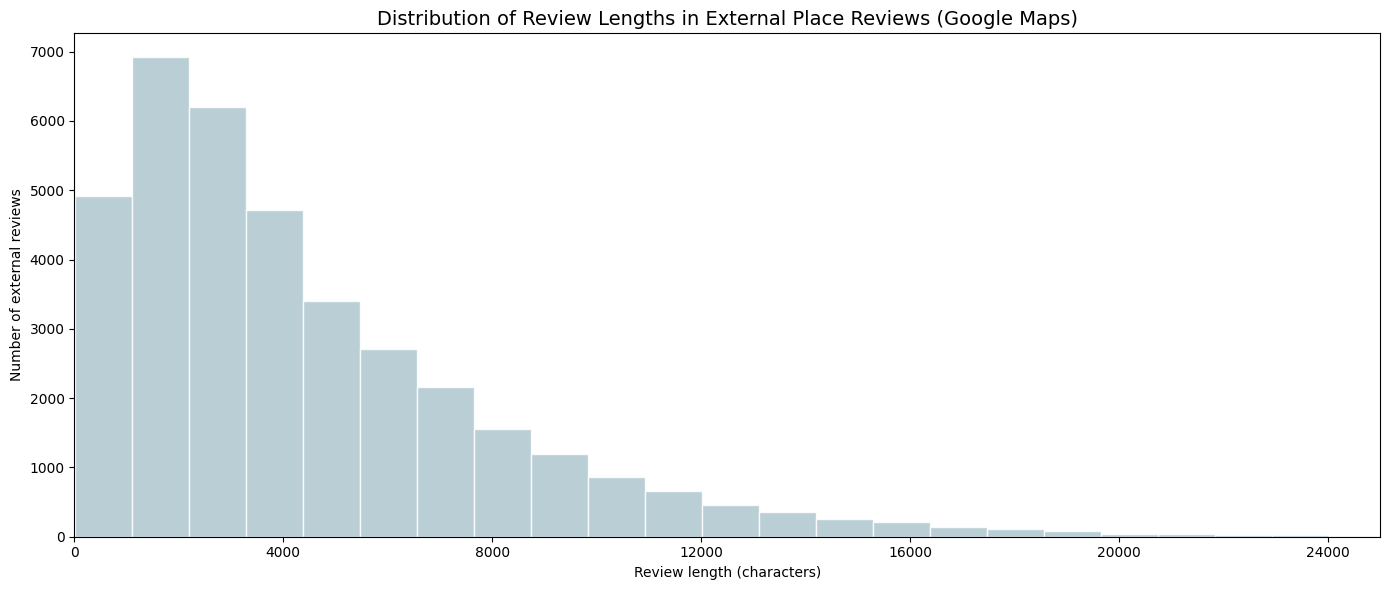

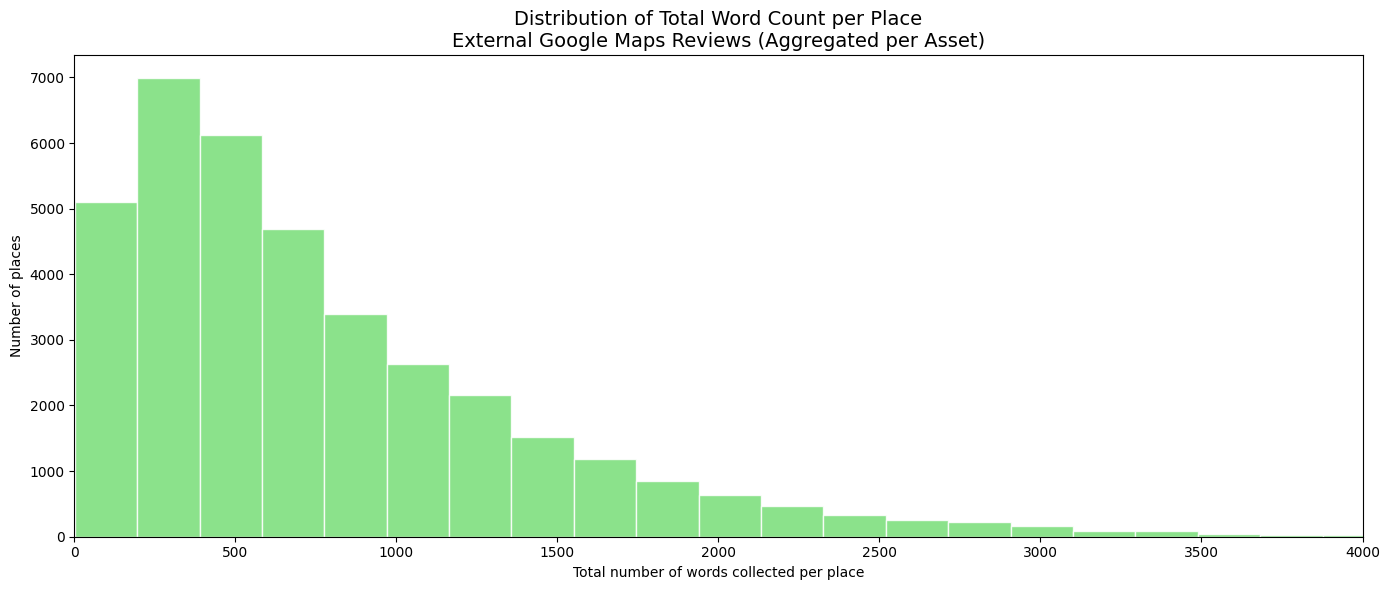

In [0]:
# SEMANTIC, LENGTH & WORD-COUNT DISTRIBUTION OF EXTERNAL REVIEWS
# Google Maps place reviews | GloVe (100d) | combined_df

import re
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, FloatType, DoubleType, IntegerType

# 1) Review → GloVe embedding (External reviews)
def tokenize(text):
    if text is None:
        return []
    return re.findall(r"[a-z]+", text.lower())

def review_to_vec(text):
    model = bc_w2v_model.value
    tokens = tokenize(text)
    vecs = [model[t] for t in tokens if t in model]
    if not vecs:
        return [0.0] * 100
    return np.mean(vecs, axis=0).astype(float).tolist()

review_vec_udf = F.udf(review_to_vec, ArrayType(FloatType()))

df = combined_df.withColumn(
    "review_vec",
    review_vec_udf(F.col("reviews_content"))
)

# 2) Review length (characters)
df = df.withColumn(
    "review_length",
    F.length(F.col("reviews_content"))
)

# 3) Word count per place (total words collected per asset)
def word_count(text):
    if text is None:
        return 0
    return len(re.findall(r"[a-zA-Z]+", text))

word_count_udf = F.udf(word_count, IntegerType())

df = df.withColumn(
    "review_word_count",
    word_count_udf(F.col("reviews_content"))
)

# 4) City-level semantic centroid
centroid_df = (
    df
    .select("city_source", "review_vec")
    .select(
        "city_source",
        F.posexplode("review_vec").alias("idx", "val")
    )
    .groupBy("city_source", "idx")
    .agg(F.avg("val").alias("val"))
    .groupBy("city_source")
    .agg(F.collect_list("val").alias("centroid_vec"))
)

# 5) Cosine distance from centroid (semantic diversity)
def cosine_distance(vec, centroid):
    if vec is None or centroid is None:
        return None
    v = np.array(vec)
    c = np.array(centroid)
    nv = np.linalg.norm(v)
    nc = np.linalg.norm(c)
    if nv == 0 or nc == 0:
        return None
    return float(1 - np.dot(v, c) / (nv * nc))

cosine_dist_udf = F.udf(cosine_distance, DoubleType())

df = (
    df.join(centroid_df, on="city_source", how="left")
      .withColumn(
          "semantic_distance",
          cosine_dist_udf(F.col("review_vec"), F.col("centroid_vec"))
      )
      .filter(F.col("semantic_distance").isNotNull())
)

# 6) Collect to Pandas for plotting
pdf = df.select(
    "semantic_distance",
    "review_length",
    "review_word_count"
).toPandas()

# Graph 1 - Semantic Gaiwan (External / Google Maps)
plt.figure(figsize=(14, 6))
plt.hist(
    pdf["semantic_distance"],
    bins=40,
    color="#B39EB5",   
    alpha=0.85,
    edgecolor="white"
)
plt.xlabel("Cosine distance from city centroid")
plt.ylabel("Number of external reviews")
plt.title(
    "Distribution of Semantic Diversity in External Urban Reviews (Google Maps)\n"
    "GloVe embeddings (100d)",
    fontsize=14
)
plt.tight_layout()
plt.show()

from matplotlib.ticker import MaxNLocator

# Graph 2 - Review length distribution (characters)
plt.figure(figsize=(14, 6))

plt.hist(
    pdf["review_length"],
    bins=40,
    color="#AEC6CF",
    alpha=0.85,
    edgecolor="white"
)

plt.xlabel("Review length (characters)")
plt.ylabel("Number of external reviews")
plt.title(
    "Distribution of Review Lengths in External Place Reviews (Google Maps)",
    fontsize=14
)

# Fix x axis
ax = plt.gca()
ax.set_xlim(0, 25000)
ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()


# Graph 3 — total word count per place 
plt.figure(figsize=(14, 6))
plt.hist(
    pdf["review_word_count"],
    bins=40,
    color="#77DD77",    
    alpha=0.85,
    edgecolor="white"
)

plt.xlabel("Total number of words collected per place")
plt.ylabel("Number of places")
plt.title(
    "Distribution of Total Word Count per Place\n"
    "External Google Maps Reviews (Aggregated per Asset)",
    fontsize=14
)
ax = plt.gca()
ax.set_xlim(0, 4000)
plt.tight_layout()
plt.show()

**Distribution of Listing Rating Categories by City:**

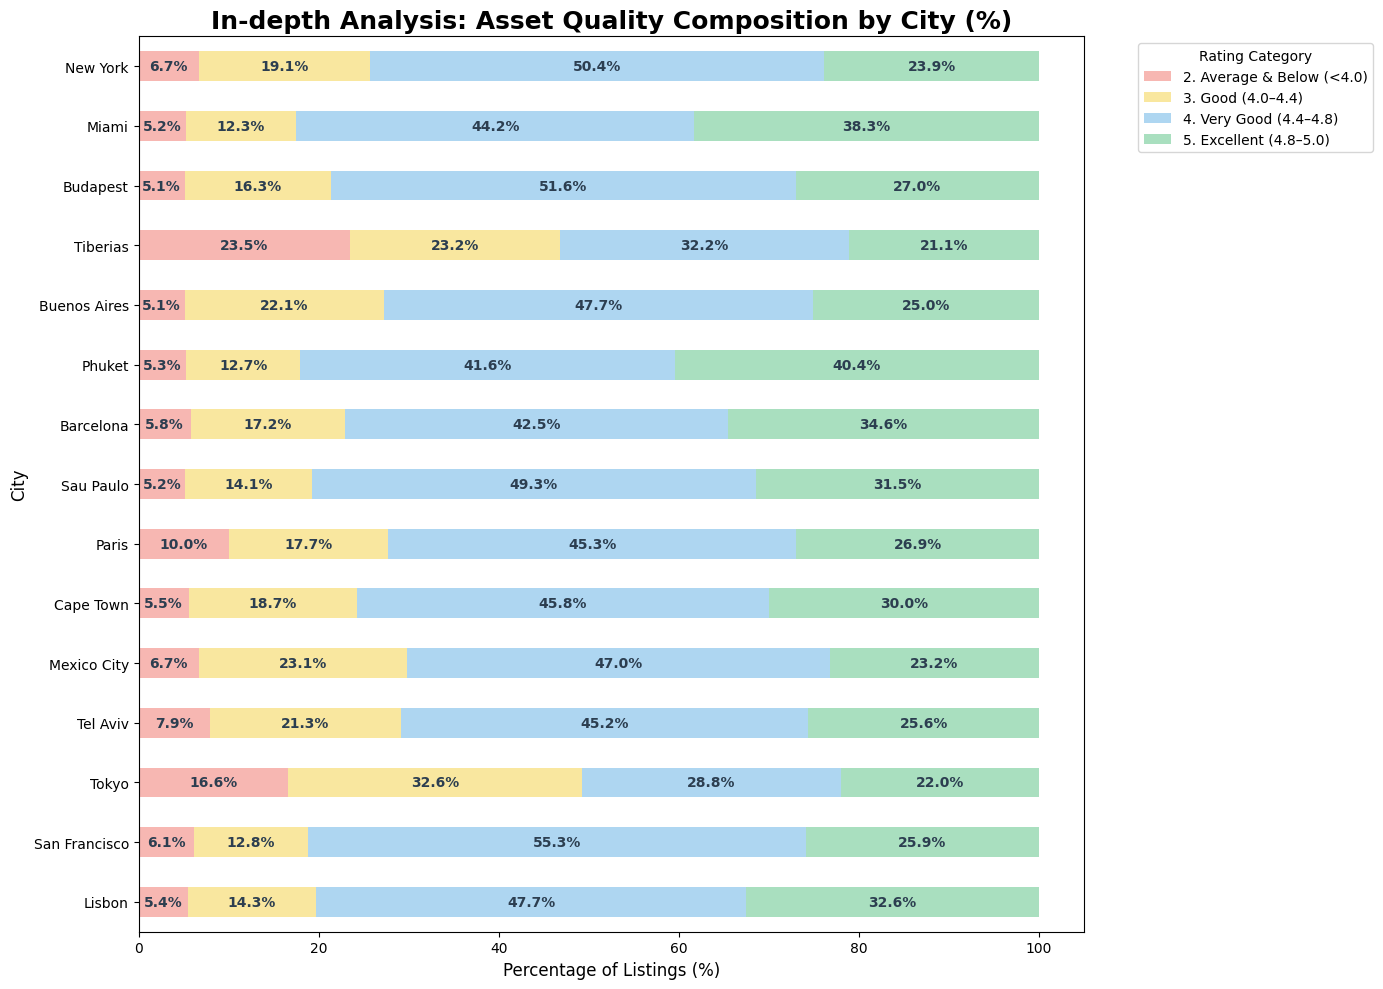

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

# 1. Creating quality categories in Spark
categorized_df = combined_df.withColumn(
    "rating_category", 
    F.when(F.col("rating") >= 4.8, "5. Excellent (4.8–5.0)")
     .when(F.col("rating") >= 4.4, "4. Very Good (4.4–4.8)")
     .when(F.col("rating") >= 4.0, "3. Good (4.0–4.4)")
     .otherwise("2. Average & Below (<4.0)")
)

# 2. Calculate percentage distribution for each city
pivot_df = (
    categorized_df
    .groupBy("city_source")
    .pivot("rating_category")
    .count()
    .fillna(0)
)

# Convert to Pandas and calculate percentages
pdf = pivot_df.toPandas().set_index("city_source")
pdf_percent = pdf.div(pdf.sum(axis=1), axis=0) * 100

# 3. Visualization: Stacked Horizontal Bar Chart 
pastel_colors = ['#f7b7b2', '#f9e79f', '#aed6f1', '#a9dfbf']

ax = pdf_percent.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 10),
    color=pastel_colors
)

# Graph design
plt.title(
    'In-depth Analysis: Asset Quality Composition by City (%)',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Percentage of Listings (%)', fontsize=12)
plt.ylabel('City', fontsize=12)

plt.legend(
    title="Rating Category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Adding percentages inside bars
for p in ax.patches:
    width = p.get_width()
    if width > 5:
        ax.annotate(
            f'{width:.1f}%',
            (p.get_x() + width / 2, p.get_y() + 0.25),
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#2c3e50'
        )

plt.tight_layout()
plt.show()